# Linear Regression Assignment: Pharma Sales Prediction

## Mission Statement
**Mission:** To optimize pharmaceutical supply chain management by accurately predicting the daily sales volume of key drug categories.
**Problem:** Pharmacies often face stockouts or overstocking due to fluctuating demand. By predicting sales based on historical patterns (seasonality, day of week), we can improve inventory management.
**Dataset:** The dataset used is 'Pharma Sales Data' (salesdaily.csv), containing daily sales volume of various drug categories (M01AB, M01AE, etc.) over several years.
**Source:** [Kaggle - Pharma Sales Data Analysis and Forecasting](https://www.kaggle.com/code/milanzdravkovic/pharma-sales-data-analysis-and-forecasting/input?select=salesdaily.csv)

## Setup and Library Imports

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.linear_model import SGDRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Set plot style
sns.set(style="whitegrid")

# Dataset URL (Raw GitHub Link for 'salesdaily.csv' from Pharma Sales Data)
# This URL is found by searching for a raw GitHub version of the Kaggle dataset
DATA_URL = "https://raw.githubusercontent.com/OrikMelancholic/Analysing-Pharmaceutical-Sales-Data/main/Analysing-pharmaceutical-sales-data/data/salesdaily.csv"
LOCAL_PICKLE_FILE = "salesdaily.pkl"

## 2. Data Loading

In [29]:
# Load Data with Caching (Pickle)
print("--- Loading Data ---")
if os.path.exists(LOCAL_PICKLE_FILE):
    print(f"Loading data from local pickle file: {LOCAL_PICKLE_FILE}")
    try:
        df = pd.read_pickle(LOCAL_PICKLE_FILE)
        print("Data loaded successfully from cache.")
    except Exception as e:
        print(f"Error reading pickle file: {e}. Re-downloading...")
        df = pd.read_csv(DATA_URL)
        df.to_pickle(LOCAL_PICKLE_FILE)
else:
    print(f"Downloading data from remote: {DATA_URL}")
    try:
        df = pd.read_csv(DATA_URL)
        print("Data downloaded successfully.")
        
        # Save to pickle for future use
        df.to_pickle(LOCAL_PICKLE_FILE)
        print(f"Data saved to local pickle file: {LOCAL_PICKLE_FILE}")
        
    except Exception as e:
        print(f"Error downloading data: {e}")
        # Only as a last resort, create dummy data so the notebook runs
        print("Creating dummy data for demonstration...")
        dates = pd.date_range(start='2014-01-01', periods=1000, freq='D')
        df = pd.DataFrame({
            'datum': dates,
            'M01AB': np.random.uniform(0, 20, size=1000),
            'M01AE': np.random.uniform(0, 15, size=1000),
            'N02BA': np.random.uniform(0, 30, size=1000),
            'N02BE': np.random.uniform(0, 50, size=1000)
        })

--- Loading Data ---
Loading data from local pickle file: salesdaily.pkl
Data loaded successfully from cache.


## 3. Initial Data Inspection

In [30]:
# Display first few rows
print(df.head())
print(df.info())

      datum  M01AB  M01AE  N02BA  N02BE  N05B  N05C   R03  R06  Year  Month  \
0  1/2/2014    0.0   3.67    3.4  32.40   7.0   0.0   0.0  2.0  2014      1   
1  1/3/2014    8.0   4.00    4.4  50.60  16.0   0.0  20.0  4.0  2014      1   
2  1/4/2014    2.0   1.00    6.5  61.85  10.0   0.0   9.0  1.0  2014      1   
3  1/5/2014    4.0   3.00    7.0  41.10   8.0   0.0   3.0  0.0  2014      1   
4  1/6/2014    5.0   1.00    4.5  21.70  16.0   2.0   6.0  2.0  2014      1   

   Hour Weekday Name  
0   248     Thursday  
1   276       Friday  
2   276     Saturday  
3   276       Sunday  
4   276       Monday  
<class 'pandas.DataFrame'>
RangeIndex: 2106 entries, 0 to 2105
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   datum         2106 non-null   str    
 1   M01AB         2106 non-null   float64
 2   M01AE         2106 non-null   float64
 3   N02BA         2106 non-null   float64
 4   N02BE         2106 non-null 

## 4. Data Profiling Summary

In [31]:
# Data Profiling Summary (for report)
print("--- df.describe() ---")
print(df.describe())

print("\n--- Quantiles (M01AB) ---")
print(df['M01AB'].quantile([0.0, 0.25, 0.5, 0.75, 0.9, 0.95, 1.0]))

print("\n--- Quantiles (M01AE) ---")
print(df['M01AE'].quantile([0.0, 0.25, 0.5, 0.75, 0.9, 0.95, 1.0]))

--- df.describe() ---
             M01AB        M01AE        N02BA        N02BE         N05B  \
count  2106.000000  2106.000000  2106.000000  2106.000000  2106.000000   
mean      5.033683     3.895830     3.880441    29.917095     8.853627   
std       2.737579     2.133337     2.384010    15.590966     5.605605   
min       0.000000     0.000000     0.000000     0.000000     0.000000   
25%       3.000000     2.340000     2.000000    19.000000     5.000000   
50%       4.990000     3.670000     3.500000    26.900000     8.000000   
75%       6.670000     5.138000     5.200000    38.300000    12.000000   
max      17.340000    14.463000    16.000000   161.000000    54.833333   

              N05C          R03          R06         Year        Month  \
count  2106.000000  2106.000000  2106.000000  2106.000000  2106.000000   
mean      0.593522     5.512262     2.900198  2016.401235     6.344255   
std       1.092988     6.428736     2.415816     1.665060     3.386954   
min       0.000

## 5. Feature Engineering: Date Extraction

In [32]:
# Feature Engineering: Extract date parts
if 'datum' in df.columns:
    df['datum'] = pd.to_datetime(df['datum'])
    df['Year'] = df['datum'].dt.year
    df['Month'] = df['datum'].dt.month
    df['Day'] = df['datum'].dt.day
    df['Weekday'] = df['datum'].dt.weekday  # 0=Monday, 6=Sunday
    df['WeekdayName'] = df['datum'].dt.day_name()
else:
    print("Warning: 'datum' column not found. EDA might be limited.")

## 6. Exploratory Data Analysis (EDA)

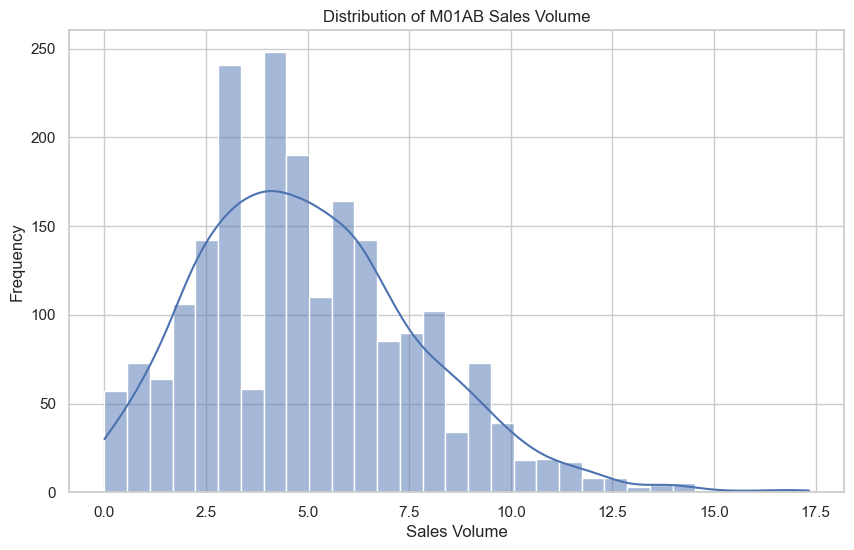

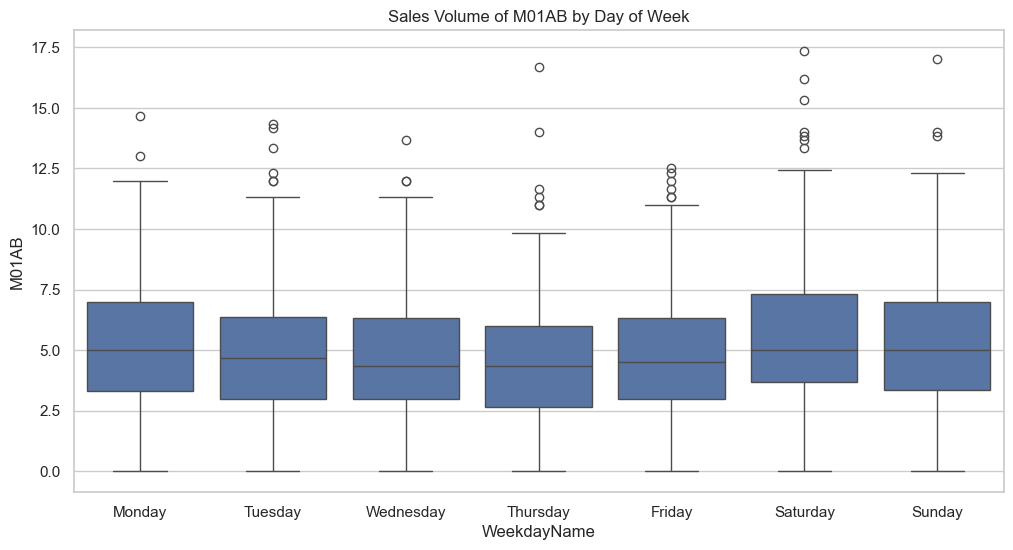

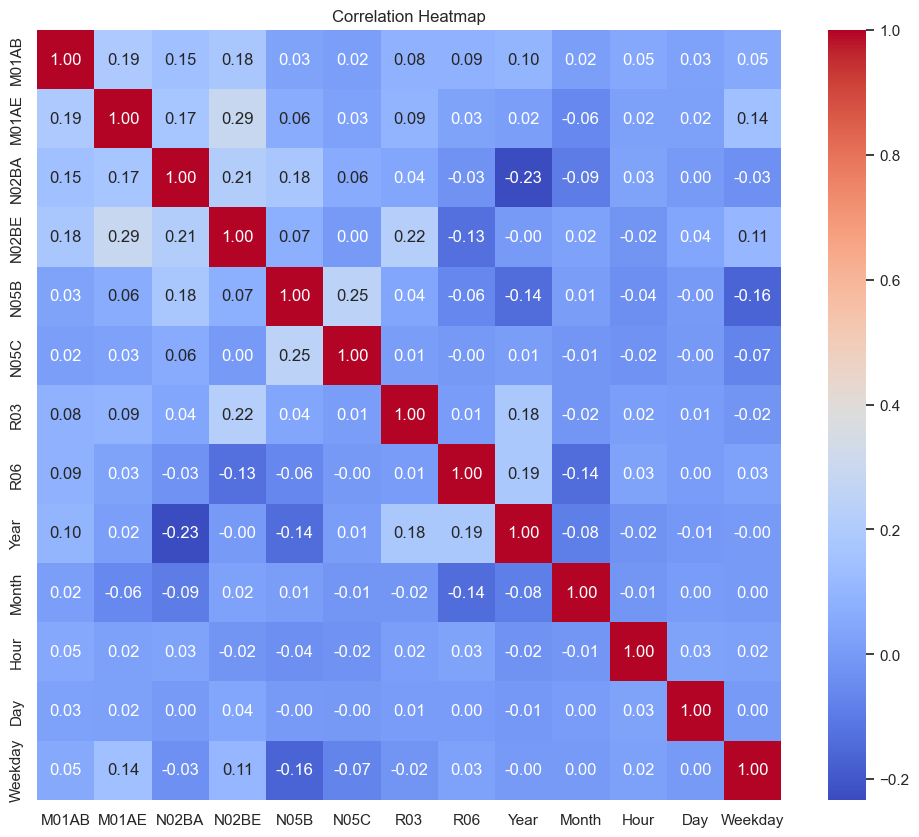

In [33]:
# Visualize Distribution of Target 'M01AB'
plt.figure(figsize=(10, 6))
sns.histplot(df['M01AB'], kde=True)
plt.title('Distribution of M01AB Sales Volume')
plt.xlabel('Sales Volume')
plt.ylabel('Frequency')
plt.show()

# Boxplot of Sales by Weekday to see variability
plt.figure(figsize=(12, 6))
sns.boxplot(x='WeekdayName', y='M01AB', data=df, order=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])
plt.title('Sales Volume of M01AB by Day of Week')
plt.show()

# Correlation Heatmap
numeric_df = df.select_dtypes(include=[np.number])
plt.figure(figsize=(12, 10))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

## 7. Data Quality Check

In [34]:
# Feature Engineering & Preprocessing

# 1. Check for Missing Values & Data Types (Interpretation)
print("--- Missing Values Before Processing ---")
print(df.isnull().sum())
print("\n--- Data Types ---")
print(df.dtypes)

--- Missing Values Before Processing ---
datum           0
M01AB           0
M01AE           0
N02BA           0
N02BE           0
N05B            0
N05C            0
R03             0
R06             0
Year            0
Month           0
Hour            0
Weekday Name    0
Day             0
Weekday         0
WeekdayName     0
dtype: int64

--- Data Types ---
datum           datetime64[us]
M01AB                  float64
M01AE                  float64
N02BA                  float64
N02BE                  float64
N05B                   float64
N05C                   float64
R03                    float64
R06                    float64
Year                     int32
Month                    int32
Hour                     int64
Weekday Name               str
Day                      int32
Weekday                  int32
WeekdayName                str
dtype: object


## 8. Preprocessing Pipeline

In [35]:
# Define Features and Target
features = ['Year', 'Month', 'Weekday']
target = 'M01AB'

# Prepare X and y
X = df[features].copy()
y = df[target].copy()

# 2. Convert Categorical to Numeric using One-Hot Encoding
print(f"\nOriginal shape: {X.shape}")

# This step converts the single 'Month' column (1-12) into MULTIPLE binary columns:
# Month_2, Month_3, ... Month_12.
# Same for Weekday.
X = pd.get_dummies(X, columns=['Month', 'Weekday'], drop_first=True)

print(f"Shape after One-Hot Encoding: {X.shape}")
print("\n--- Generated Columns (Notice how 'Month' became many columns) ---")
print(X.columns.tolist())
# NOTE: 'Month_1' (January) is implicit. If Month_2 ... Month_12 are ALL 0, then it is January.

# 3. Handle Missing Values (Advanced Imputation)
# Strategy:
# A. For Numeric Features (Year): Use MEAN.
if 'Year' in X.columns:
    X['Year'] = X['Year'].fillna(X['Year'].mean())

# B. For One-Hot Encoded Features: Use 0.
#    Since these are simple "Yes/No" flags (e.g., Is it February?), filling with 0 (No) is safe.
X = X.fillna(0)  

print("Missing values handled using Hybrid Strategy.")

# Split the data into Training and Testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Standardize the Data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nData Preprocessing Complete.")
print(f"Training Shape: {X_train_scaled.shape}")
print(f"Test Shape: {X_test_scaled.shape}")


Original shape: (2106, 3)
Shape after One-Hot Encoding: (2106, 18)

--- Generated Columns (Notice how 'Month' became many columns) ---
['Year', 'Month_2', 'Month_3', 'Month_4', 'Month_5', 'Month_6', 'Month_7', 'Month_8', 'Month_9', 'Month_10', 'Month_11', 'Month_12', 'Weekday_1', 'Weekday_2', 'Weekday_3', 'Weekday_4', 'Weekday_5', 'Weekday_6']
Missing values handled using Hybrid Strategy.

Data Preprocessing Complete.
Training Shape: (1684, 18)
Test Shape: (422, 18)


## 9. Model Training 1: SGD Linear Regression

Final Train MSE: 8.01002594932732
Final Test MSE: 8.047475881505763


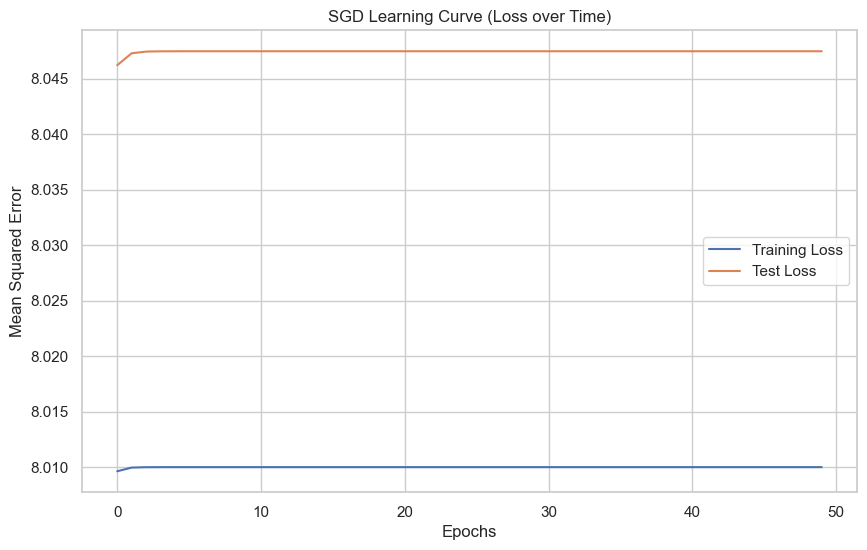

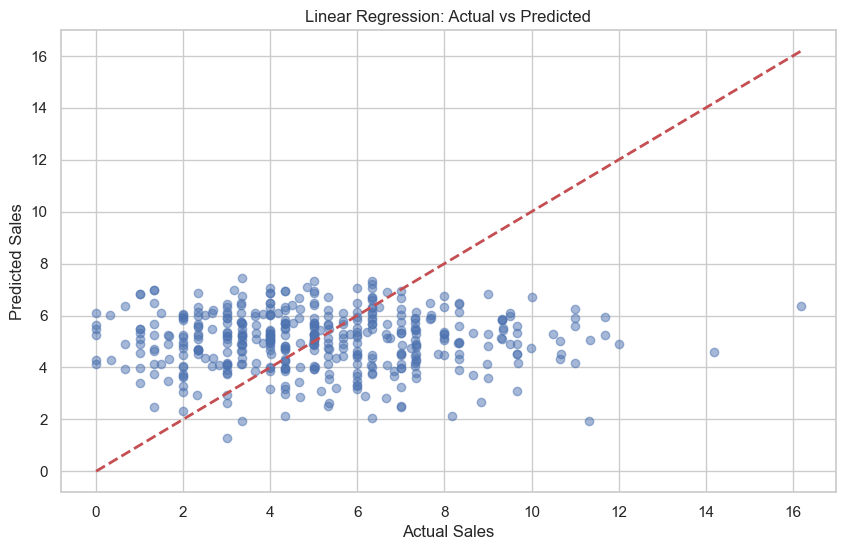

In [36]:
# Model 1: Gradient Descent Linear Regression (SGD)
# Initialize SGDRegressor with warm_start to track loss manually
sgd_reg = SGDRegressor(max_iter=1000, tol=1e-3, penalty=None, learning_rate='constant', eta0=0.01, random_state=42)

# Training loop to capture loss at each epoch
train_losses = []
test_losses = []
epochs = 50

# For plotting loss curve
for epoch in range(epochs):
    sgd_reg.partial_fit(X_train_scaled, y_train)
    
    # Calculate MSE
    y_train_pred = sgd_reg.predict(X_train_scaled)
    y_test_pred = sgd_reg.predict(X_test_scaled)
    
    train_mse = mean_squared_error(y_train, y_train_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)
    
    train_losses.append(train_mse)
    test_losses.append(test_mse)

print(f"Final Train MSE: {train_losses[-1]}")
print(f"Final Test MSE: {test_losses[-1]}")

# Plot Loss Curve
plt.figure(figsize=(10, 6))
plt.plot(range(epochs), train_losses, label='Training Loss')
plt.plot(range(epochs), test_losses, label='Test Loss')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error')
plt.title('SGD Learning Curve (Loss over Time)')
plt.legend()
plt.show()

# Scatter Plot: Actual vs Predicted (Linear Regression)
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_test_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.title('Linear Regression: Actual vs Predicted')
plt.show()

## 10. Model Training 2: Decision Tree

In [ ]:
# Model 2: Decision Tree Regressor
dt_reg = DecisionTreeRegressor(max_depth=10, random_state=42)
dt_reg.fit(X_train_scaled, y_train)
y_pred_dt = dt_reg.predict(X_test_scaled)
mse_dt = mean_squared_error(y_test, y_pred_dt)
r2_dt = r2_score(y_test, y_pred_dt)

print(f"Decision Tree MSE: {mse_dt:.4f}")
print(f"Decision Tree R2: {r2_dt:.4f}")

# Visualizing Decision Tree Performance
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_dt, alpha=0.5, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.title('Decision Tree: Actual vs Predicted')
plt.show()

## 11. Model Training 3: Random Forest

In [ ]:
# Model 3: Random Forest Regressor
rf_reg = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
rf_reg.fit(X_train_scaled, y_train)
y_pred_rf = rf_reg.predict(X_test_scaled)
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f"Random Forest MSE: {mse_rf:.4f}")
print(f"Random Forest R2: {r2_rf:.4f}")

# Visualizing Random Forest Performance
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_rf, alpha=0.5, color='orange')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.title('Random Forest: Actual vs Predicted')
plt.show()

## 12. Model Comparison and Selection

In [ ]:
# Compare and Select Best Model
results = pd.DataFrame({
    'Model': ['SGD Linear Regression', 'Decision Tree', 'Random Forest'],
    'MSE': [test_losses[-1], mse_dt, mse_rf],
    'R2': [r2_score(y_test, y_test_pred), r2_dt, r2_rf]
})

print("\nModel Comparison:")
print(results)

## 13. Evaluation Metrics Visualization

In [ ]:
# Visualize Model Comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# MSE Comparison
sns.barplot(x='Model', y='MSE', data=results, ax=axes[0], palette='viridis')
axes[0].set_title('Model Comparison: Mean Squared Error (Lower is Better)')
axes[0].set_ylabel('MSE')
axes[0].tick_params(axis='x', rotation=45)

# R2 Comparison
sns.barplot(x='Model', y='R2', data=results, ax=axes[1], palette='magma')
axes[1].set_title('Model Comparison: R2 Score (Higher is Better)')
axes[1].set_ylabel('R2 Score')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 14. Best Model Selection & Saving

In [ ]:
# Select Best Model
best_model_idx = results['MSE'].idxmin()
best_model_name = results.loc[best_model_idx, 'Model']
print(f"\nBest Performing Model: {best_model_name}")

if best_model_name == 'SGD Linear Regression':
    best_model = sgd_reg
elif best_model_name == 'Decision Tree':
    best_model = dt_reg
else:
    best_model = rf_reg

# Save the best model
joblib.dump(best_model, 'best_model.pkl')
joblib.dump(scaler, 'scaler.pkl') # Save scaler for future predictions
print("Best model and scaler saved successfully.")

## 15. Prediction Script

In [44]:
# Prediction Script (Task 2 Implementation)
import pandas as pd
import joblib

def predict_sales(year, month, weekday, best_model, scaler, original_columns):
    # 1. Create DataFrame for Input
    input_data = pd.DataFrame({'Year': [year], 'Month': [month], 'Weekday': [weekday]})
    
    # 2. Preprocess Input (One-Hot Encoding)
    # Note: We do NOT use drop_first=True here because we want to generate the specific column for the input value.
    # The reindex step will align it with the training columns (dropping the reference category if needed).
    input_encoded = pd.get_dummies(input_data, columns=['Month', 'Weekday'])
    
    # 3. Align with Training Columns
    # This ensures all model features are present (filled with 0) and extra features are ignored.
    input_final = input_encoded.reindex(columns=original_columns, fill_value=0)
    
    # 4. Scale Data
    input_scaled = scaler.transform(input_final)
    
    # 5. Predict
    prediction = best_model.predict(input_scaled)
    return prediction[0]

# --- USAGE ---
# Identify the best model again (assuming run in notebook order)
# (In a real script, you would load 'best_model.pkl' and 'scaler.pkl')

best_model_loaded = best_model # Assume 'best_model' variable from previous cell
scaler_loaded = scaler # Assume 'scaler' variable from previous cell
training_columns = X.columns # X is available from previous cells

print("--- MAKING PREDICTIONS ---")

# Example 1: Predict for a Friday (Weekday=4) in December (Month=12), 2024
# Note: Weekday 4 is Friday (0=Monday)
pred_1 = predict_sales(year=2024, month=12, weekday=4, 
                       best_model=best_model_loaded, 
                       scaler=scaler_loaded, 
                       original_columns=training_columns)
print(f"Predicted Sales for Friday, Dec 2024: {pred_1:.2f}")

# Example 2: Predict using the first row of actual data to compare
sample_row = df.iloc[0]
actual_val = sample_row['M01AB']
year_val = sample_row['Year']
month_val = sample_row['Month']
weekday_val = sample_row['Weekday']

pred_2 = predict_sales(year_val, month_val, weekday_val, best_model_loaded, scaler_loaded, training_columns)

print(f"\n--- VALIDATION ON FIRST DISCOVERED ROW ---")
print(f"Sample Date: {sample_row.get('datum', 'N/A')}")
print(f"Features: Year={year_val}, Month={month_val}, Weekday={weekday_val}")
print(f"Actual Sales: {actual_val:.2f}")
print(f"Predicted Sales: {pred_2:.2f}")
print(f"Difference: {abs(actual_val - pred_2):.2f}")

--- MAKING PREDICTIONS ---
Predicted Sales for Friday, Dec 2024: 5.57

--- VALIDATION ON FIRST DISCOVERED ROW ---
Sample Date: 2014-01-02 00:00:00
Features: Year=2014, Month=1, Weekday=3
Actual Sales: 0.00
Predicted Sales: 3.61
Difference: 3.61
